# VEO Descriptive Analysis

Comprehensive descriptive analysis of generative model (VEO) performance on visual search tasks including success rates, failure type distributions, and generative fidelity metrics.

**Key Output Variable**: `generative_success` - per-bin per-condition average success rate (main dependent variable for downstream hypothesis testing)

## 0. setup

### Load Data etc

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
!python --version

Python 3.12.1


In [5]:
# Load VEO results data
veo_data = pd.read_csv('../veo_results/mergedVeo3.csv')
print(f"Data loaded: {veo_data.shape[0]} rows, {veo_data.shape[1]} columns")
print(f"\nFirst few rows:")
print(veo_data.head())
print(f"\nColumns: {veo_data.columns.tolist()}")
# Explicitly convert numeric columns to numeric types (ensure strings don't sneak in)
numeric_cols = ['success', 'bin_y', 'num_distractors'] + [col for col in veo_data.columns if col.startswith('err_')] + [col for col in veo_data.columns if col.startswith('fidelity_')]

for col in numeric_cols:
    if col in veo_data.columns:
        veo_data[col] = pd.to_numeric(veo_data[col], errors='coerce')

print("\n✓ All numeric columns converted to numeric types")

Data loaded: 114 rows, 52 columns

First few rows:
                   video_filename      condition  bin_x  source_image  \
0  2Among5Colour_Bin3_Sample6.mp4  2Among5Colour    3.0   image_1.png   
1  2Among5Colour_Bin4_Sample2.mp4  2Among5Colour    4.0   image_3.png   
2  2Among5Colour_Bin3_Sample3.mp4  2Among5Colour    3.0   image_4.png   
3  2Among5Colour_Bin5_Sample5.mp4  2Among5Colour    5.0   image_7.png   
4  2Among5Colour_Bin6_Sample2.mp4  2Among5Colour    6.0  image_20.png   

      status             image_condition  shape_type  target    center_x  \
0  submitted   image_1.png_2Among5Colour           2    True  470.517120   
1  submitted   image_3.png_2Among5Colour           2    True  218.354464   
2  submitted   image_4.png_2Among5Colour           2    True  170.339160   
3  submitted   image_7.png_2Among5Colour           2    True  306.152451   
4  submitted  image_20.png_2Among5Colour           2    True  143.470013   

     center_y  ...  err_id_change_after err_vanishing

In [6]:
# Verify data types - ensure all numeric columns are actually numeric
print("=" * 60)
print("DATA TYPE VERIFICATION")
print("=" * 60)

print("\nNumeric columns and their dtypes:")
numeric_cols_check = [col for col in veo_data.columns if veo_data[col].dtype in ['int64', 'float64', 'int32', 'float32']]
for col in numeric_cols_check:
    print(f"  {col}: {veo_data[col].dtype}")

# Check for any remaining string columns that should be numeric
print("\nString/Object columns (text data):")
string_cols = [col for col in veo_data.columns if veo_data[col].dtype == 'object']
for col in string_cols[:10]:  # Show first 10
    print(f"  {col}: {veo_data[col].dtype}")

# Summary
print(f"\nTotal numeric columns: {len(numeric_cols_check)}")
print(f"Total string/object columns: {len(string_cols)}")
print("\n✓ Data types verified and ready for analysis")

DATA TYPE VERIFICATION

Numeric columns and their dtypes:
  bin_x: float64
  shape_type: int64
  center_x: float64
  center_y: float64
  size: int64
  row: int64
  column: int64
  num_distractors: int64
  num_images: float64
  color_bin_index: float64
  rotation_angle: float64
  bin_group: int64
  trial_index: int64
  bin_y: int64
  sample: int64
  success: int64
  err_no_distractors: int64
  err_no_target: int64
  err_wrong_manip: int64
  err_new_target_id: int64
  err_new_target_unid: int64
  err_extra_distractors: int64
  err_font_change: int64
  err_rotation: int64
  err_movement: int64
  err_enlarge_target: int64
  err_enlarge_distractors: int64
  err_target_centre: int64
  err_circular_motion: int64
  err_merging: int64
  err_id_change_before: int64
  err_id_change_after: int64
  err_vanishing: int64
  fidelity_omission: int64
  fidelity_addition: int64
  fidelity_manipulation: int64
  fidelity_temporal: int64
  fidelity_score_total: int64

String/Object columns (text data):

Tot

In [ ]:
# Data Overview and Exploration
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nUnique conditions: {sorted(veo_data['condition'].unique())}")
print(f"Number of unique conditions: {veo_data['condition'].nunique()}")
print(f"\nUnique bins: {sorted(veo_data['bin_y'].unique())}")
print(f"Number of unique bins: {veo_data['bin_y'].nunique()}")
print(f"\nMissing values:\n{veo_data.isnull().sum()}")

DATA OVERVIEW

Unique conditions: ['2Among5Colour', '2Among5ConjRed', '2Among5NoColour', 'NoDistractors']
Number of unique conditions: 4

Unique bins: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Number of unique bins: 7

Missing values:
video_filename               0
condition                    0
bin_x                        0
source_image                 0
status                       0
image_condition              0
shape_type                   0
target                       0
center_x                     0
center_y                     0
size                         0
color                        0
quadrant                     0
row                          0
column                       0
num_distractors              0
num_images                   0
distractor_color             0
color_bin_index              0
rotation_angle               0
bin_group                    0
trial_index                  0
condition.1                  0
bi

### Cohen's Kappa

In [4]:
### Marker 1 vs Marker 2 
from sklearn.metrics import cohen_kappa_score
# load data
Markerdata = pd.read_csv("../Analysis/MarkerMerged.csv", sep = ",")

Kappa_df = Markerdata[['success', 'success_DK']].dropna(subset=['success_DK'])
print(Kappa_df.shape)
# success measues
kappa = cohen_kappa_score(Kappa_df['success'], Kappa_df['success_DK'])
print(f"Cohen's Kappa: {kappa:.3f}")
print(Markerdata['failure_type_DK'].value_counts(dropna=False))

# disagreement rws
disagreements = Markerdata[['video_name', 'condition', 'bin', 'success', 'success_DK', 'failure_type']].dropna(subset=['success_DK'])
disagreements = disagreements[disagreements['success'] != disagreements['success_DK']]
print(disagreements)

## error types agreement 
kappa_error_df = Markerdata[['fidelity_score_total', 'fidelity_score_total_DK']].dropna(subset=['fidelity_score_total_DK'])
kapa_error = cohen_kappa_score(kappa_error_df['fidelity_score_total'], kappa_error_df['fidelity_score_total_DK'])
print(f"Cohen's Kappa for error types: {kapa_error:.3f}")

# make subset per error type agreement!!! 
err_cols = ['err_no_distractors', 'err_no_target', 'err_wrong_manip', 'err_new_target_id', 'err_new_target_unid', 'err_extra_distractors', 'err_font_change', 'err_rotation', 'err_movement', 'err_enlarge_target', 'err_enlarge_distractors', 'err_target_centre', 'err_circular_motion', 'err_merging', 'err_id_change_before', 'err_id_change_after', 'err_vanishing']


for col in err_cols:
    col_dk = col + '_DK'
    subset = Markerdata[[col, col_dk]].dropna()
    kappa = cohen_kappa_score(subset[col], subset[col_dk])
    print(f"Cohen's Kappa for {col}: {kappa:.3f}")


(36, 2)
Cohen's Kappa: 0.683
failure_type_DK
NaN               91
new_generation    21
location           2
Name: count, dtype: int64
                          video_name        condition  bin  success  \
15    2Among5Colour_Bin3_Sample4.mp4    2Among5Colour    3        0   
25    2Among5Colour_Bin5_Sample2.mp4    2Among5Colour    5        0   
27    2Among5Colour_Bin5_Sample4.mp4    2Among5Colour    5        0   
34    2Among5Colour_Bin6_Sample5.mp4    2Among5Colour    6        0   
73  2Among5NoColour_Bin1_Sample2.mp4  2Among5NoColour    1        1   

    success_DK failure_type  
15         1.0    ambiguity  
25         1.0    ambiguity  
27         1.0    ambiguity  
34         1.0    ambiguity  
73         0.0          NaN  
Cohen's Kappa for error types: 0.142
Cohen's Kappa for err_no_distractors: nan
Cohen's Kappa for err_no_target: nan
Cohen's Kappa for err_wrong_manip: -0.071
Cohen's Kappa for err_new_target_id: 0.667
Cohen's Kappa for err_new_target_unid: 0.300
Cohen's Kappa

In [19]:
# remarking of ambiguity cases by Marker 3 
Marker2data = pd.read_csv("MarkerMerged2.csv", sep=',')
Kappa_df2 = Marker2data[['success', 'success_FR']].dropna(subset=['success_FR'])
print(Kappa_df2.shape)
# success measues
kappa2 = cohen_kappa_score(Kappa_df2['success'], Kappa_df2['success_FR'])
print(f"Cohen's Kappa: {kappa2:.3f}")

# disagreement rws
disagreements2 = Marker2data[['video_name', 'condition', 'bin', 'success', 'success_FR', 'failure_type_FR']].dropna(subset=['success_FR'])
disagreements2 = disagreements2[disagreements2['success'] != disagreements2['success_FR']]
print(disagreements2)

(15, 2)
Cohen's Kappa: 0.634
                        video_name      condition  bin  success  success_FR  \
12  2Among5Colour_Bin3_Sample1.mp4  2Among5Colour    3        0         1.0   

   failure_type_FR  
12             NaN  


## 1. Overall Success Rate

In [7]:
print(veo_data.columns)
overall_success = veo_data['success'].mean()
n_success = veo_data['success'].sum()
n_failure = veo_data['success'].eq(0).sum()
n_total = len(veo_data)
# success distribution
print("=" * 60)
print("OVERALL SUCCESS RATE")
print("=" * 60)
print(f"Success Rate: {overall_success:.4f}")
print(f"Successes: {int(n_success)}")
print(f"Total Trials: {n_total}")
print(f"Failures: {int(n_failure)}")

# failure types
failure_types = veo_data[veo_data['success']==0]['failure_type'].unique()
failure_types_sorted = sorted([ft for ft in failure_types if pd.notna(ft)])
print(f"\nFailure types: {failure_types_sorted}")

# percentages
failure_type_counts = veo_data[veo_data['success']==0]['failure_type'].value_counts()
print(f"\nFailure type counts (with % of total failures):")
for ft, count in failure_type_counts.items():
    pct = (count / int(n_failure)) * 100
    print(f"  {ft}: {count} ({pct:.2f}%)")

# exclude no distractors control condition
no_success_overall = veo_data[veo_data['num_distractors'] != 0]['success'].mean()
no_n_success = veo_data[veo_data['num_distractors'] != 0]['success'].sum()
no_n_failure = veo_data[veo_data['num_distractors'] != 0]['success'].eq(0).sum()
no_n_total = veo_data[veo_data['num_distractors'] != 0].shape[0]

print("=" * 60)
print("SUCCESS RATE EXCLUDING CONTROL CONDITION (NO DISTRACTORS)")
print("=" * 60)
print(f"Success Rate (excluding no distractors): {no_success_overall:.4f}")
print(f"Successes (excluding no distractors): {int(no_n_success)}")
print(f"Total Trials (excluding no distractors): {no_n_total}")
print(f"Failures (excluding no distractors): {int(no_n_failure)}")


Index(['video_filename', 'condition', 'bin_x', 'source_image', 'status',
       'image_condition', 'shape_type', 'target', 'center_x', 'center_y',
       'size', 'color', 'quadrant', 'row', 'column', 'num_distractors',
       'num_images', 'distractor_color', 'color_bin_index', 'rotation_angle',
       'bin_group', 'trial_index', 'condition.1', 'bin_y', 'sample', 'success',
       'failure_type', 'err_no_distractors', 'err_no_target',
       'err_wrong_manip', 'err_new_target_id', 'err_new_target_unid',
       'err_extra_distractors', 'err_font_change', 'err_rotation',
       'err_movement', 'err_enlarge_target', 'err_enlarge_distractors',
       'err_target_centre', 'err_circular_motion', 'err_merging',
       'err_id_change_before', 'err_id_change_after', 'err_vanishing', 'notes',
       'coder', 'timestamp', 'fidelity_omission', 'fidelity_addition',
       'fidelity_manipulation', 'fidelity_temporal', 'fidelity_score_total'],
      dtype='str')
OVERALL SUCCESS RATE
Success Rate: 0.2

## 2. Generative Success: Per Bin Per Condition (Main DV DF)

In [8]:
print("=" * 60)
print("GENERATIVE SUCCESS BY CONDITION AND BIN")
print("=" * 60)

# Calculate generative_success: average success rate per bin per condition
generative_success = veo_data.groupby(['condition', 'bin_y'])['success'].agg(
    ['mean', 'sum', 'count', 'std']
).reset_index()

generative_success.columns = ['condition', 'bin', 'generative_success', 'n_success', 'n_total', 'se_success']

# Calculate 95% CI for each bin-condition combination
ci_lower = []
ci_upper = []
for idx, row in generative_success.iterrows():
    p = row['generative_success']
    n = row['n_total']
    se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
    ci_lower.append(p - 1.96 * se)
    ci_upper.append(p + 1.96 * se)

generative_success['ci_lower'] = ci_lower
generative_success['ci_upper'] = ci_upper

print("\nGenerative Success Rates (per Condition × Bin):")
print(generative_success.to_string(index=False))

# Export to CSV for downstream analysis
generative_success.to_csv('../Analysis/generative_success.csv', index=False)
print("\n✓ Saved to: Analysis/generative_success.csv")

GENERATIVE SUCCESS BY CONDITION AND BIN

Generative Success Rates (per Condition × Bin):
      condition  bin  generative_success  n_success  n_total  se_success  ci_lower  ci_upper
  2Among5Colour    1            0.833333          5        6    0.408248  0.535129  1.131538
  2Among5Colour    2            0.666667          4        6    0.516398  0.289464  1.043869
  2Among5Colour    3            0.333333          2        6    0.516398 -0.043869  0.710536
  2Among5Colour    4            0.333333          2        6    0.516398 -0.043869  0.710536
  2Among5Colour    5            0.166667          1        6    0.408248 -0.131538  0.464871
  2Among5Colour    6            0.500000          3        6    0.547723  0.099917  0.900083
 2Among5ConjRed    1            0.833333          5        6    0.408248  0.535129  1.131538
 2Among5ConjRed    2            0.000000          0        6    0.000000  0.000000  0.000000
 2Among5ConjRed    3            0.166667          1        6    0.408248 -

## 3. Success Rate by Condition

In [12]:
success_by_condition = veo_data.groupby('condition')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_condition.columns = ['condition', 'success_rate', 'n_success', 'n_total']

print("\nSuccess Rate by Condition:")
print(success_by_condition.to_string(index=False))

# Also by bin (collapsed across conditions)
success_by_bin = veo_data.groupby('bin_y')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_bin.columns = ['bin', 'success_rate', 'n_success', 'n_total']

print("\n\nSuccess Rate by Bin (Overall):")
print(success_by_bin.to_string(index=False))


Success Rate by Condition:
      condition  success_rate  n_success  n_total
  2Among5Colour      0.472222         17       36
 2Among5ConjRed      0.166667          6       36
2Among5NoColour      0.138889          5       36
  NoDistractors      1.000000          6        6


Success Rate by Bin (Overall):
 bin  success_rate  n_success  n_total
   0      1.000000          6        6
   1      0.777778         14       18
   2      0.222222          4       18
   3      0.222222          4       18
   4      0.111111          2       18
   5      0.055556          1       18
   6      0.166667          3       18


## 3.1 visualization

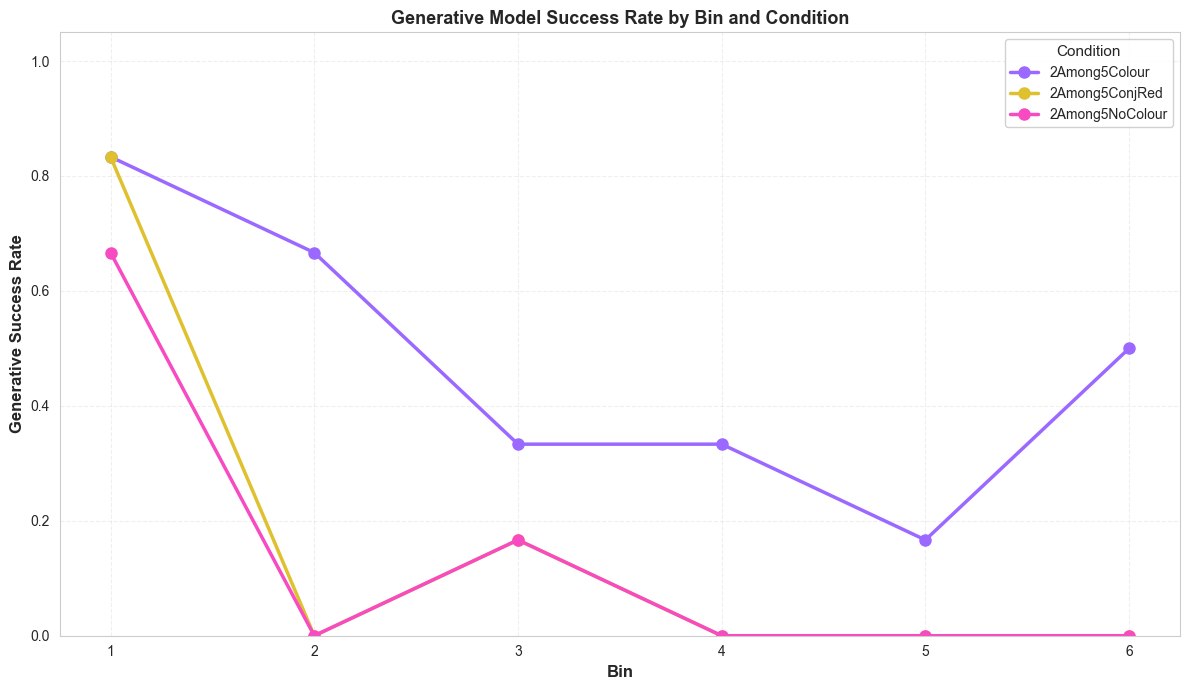

In [13]:
# Plot generative success by bin with lines for each condition
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each condition
colours = {
    '2Among5Colour': "#9B69FF",
    '2Among5ConjRed': "#DFC12F",
    '2Among5NoColour': "#F84AC1",

}
NoDistractorsExl = generative_success[
    (generative_success['condition'] != 'NoDistractors') & 
    (generative_success['bin'] != 0)
]
# Get unique conditions and bins
conditions = sorted(NoDistractorsExl['condition'].unique())
bins = sorted(NoDistractorsExl['bin'].unique())

# Create x-axis labels with bin ranges
# Assuming bins are numbered 1, 2, 3, etc. representing ranges
bin_labels = [f"{int(b)}" for b in bins]

# Plot line for each condition
for condition in conditions:
    condition_data = NoDistractorsExl[NoDistractorsExl['condition'] == condition].sort_values('bin')
    color = colours.get(condition, "#333333")  # Default color if condition not in dict
    ax.plot(condition_data['bin'], condition_data['generative_success'], 
            marker='o', linewidth=2.5, markersize=8, label=condition, color=color)

# Formatting
ax.set_xlabel('Bin', fontsize=12, fontweight='bold')
ax.set_ylabel('Generative Success Rate', fontsize=12, fontweight='bold')
ax.set_title('Generative Model Success Rate by Bin and Condition', fontsize=13, fontweight='bold')
ax.set_xticks(bins)
ax.set_xticklabels(bin_labels)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(title='Condition', fontsize=10, title_fontsize=11, loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()


## 4. subsetted where ambiguity = success 

In [22]:

AmbiguityAsSuccess = veo_data.copy()
AmbiguityAsSuccess.loc[AmbiguityAsSuccess['failure_type'] == 'ambiguity', 'success'] = 1
AmbiguityAsSuccess.to_csv('../Analysis/AmbiguityAsSuccess.csv', index=False)
# failure types
failure_types_AS = AmbiguityAsSuccess[AmbiguityAsSuccess['success']==0]['failure_type'].unique()
failure_types_sorted_AS = sorted([ft for ft in failure_types_AS if pd.notna(ft)])
print(f"\nFailure types: {failure_types_sorted_AS}")
failure_type_counts_AS = AmbiguityAsSuccess[AmbiguityAsSuccess['success']==0]['failure_type'].value_counts()
print(f"\nFailure type counts (with % of total failures):")
for ft, count in failure_type_counts_AS.items():
    pct = (count / int(n_failure)) * 100
    print(f"  {ft}: {count} ({pct:.2f}%)")

# by condition
success_by_condition_AS = AmbiguityAsSuccess.groupby('condition')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_condition_AS.columns = ['condition', 'success_rate', 'n_success', 'n_total']

print("\nSuccess Rate by Condition:")
print(success_by_condition_AS.to_string(index=False))

# Also by bin (collapsed across conditions)
success_by_bin_AS = AmbiguityAsSuccess.groupby('bin_y')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_bin_AS.columns = ['bin', 'success_rate', 'n_success', 'n_total']

print("\n\nSuccess Rate by Bin (Overall):")
print(success_by_bin_AS.to_string(index=False))


## generate CSV
# Calculate generative_success: average success rate per bin per condition
generative_success_AS = AmbiguityAsSuccess.groupby(['condition', 'bin_y'])['success'].agg(
    ['mean', 'sum', 'count', 'std']
).reset_index()

generative_success_AS.columns = ['condition', 'bin', 'generative_success', 'n_success', 'n_total', 'se_success']

# Calculate 95% CI for each bin-condition combination
ci_lower = []
ci_upper = []
for idx, row in generative_success_AS.iterrows():
    p = row['generative_success']
    n = row['n_total']
    se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
    ci_lower.append(p - 1.96 * se)
    ci_upper.append(p + 1.96 * se)

generative_success_AS['ci_lower'] = ci_lower
generative_success_AS['ci_upper'] = ci_upper
generative_success_AS['se_success'] = np.sqrt(
    generative_success_AS['generative_success'] * 
    (1 - generative_success_AS['generative_success']) / 
    generative_success_AS['n_total']
)

print("\nGenerative Success Rates (per Condition × Bin):")
print(generative_success_AS.to_string(index=False))

# Export to CSV for downstream analysis
generative_success_AS.to_csv('../Analysis/generative_success_AS.csv', index=False)
print("\n✓ Saved to: Analysis/generative_success_AS.csv")


Failure types: ['location', 'new_generation']

Failure type counts (with % of total failures):
  new_generation: 63 (78.75%)
  location: 2 (2.50%)

Success Rate by Condition:
      condition  success_rate  n_success  n_total
  2Among5Colour      0.805556         29       36
 2Among5ConjRed      0.194444          7       36
2Among5NoColour      0.194444          7       36
  NoDistractors      1.000000          6        6


Success Rate by Bin (Overall):
 bin  success_rate  n_success  n_total
   0      1.000000          6        6
   1      0.833333         15       18
   2      0.277778          5       18
   3      0.388889          7       18
   4      0.333333          6       18
   5      0.222222          4       18
   6      0.333333          6       18

Generative Success Rates (per Condition × Bin):
      condition  bin  generative_success  n_success  n_total  se_success  ci_lower  ci_upper
  2Among5Colour    1            0.833333          5        6    0.152145  0.535129  1.1

In [12]:
## generate CSV
# Calculate generative_success: average success rate per bin per condition
generative_success_AS = AmbiguityAsSuccess.groupby(['condition', 'bin_y'])['success'].agg(
    ['mean', 'sum', 'count', 'std']
).reset_index()

generative_success_AS.columns = ['condition', 'bin', 'generative_success', 'n_success', 'n_total', 'se_success']

# Calculate 95% CI for each bin-condition combination
ci_lower = []
ci_upper = []
for idx, row in generative_success_AS.iterrows():
    p = row['generative_success']
    n = row['n_total']
    se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
    ci_lower.append(p - 1.96 * se)
    ci_upper.append(p + 1.96 * se)

generative_success_AS['ci_lower'] = ci_lower
generative_success_AS['ci_upper'] = ci_upper
generative_success_AS['se_success'] = np.sqrt(
    generative_success_AS['generative_success'] * 
    (1 - generative_success_AS['generative_success']) / 
    generative_success_AS['n_total']
)

print("\nGenerative Success Rates (per Condition × Bin):")
print(generative_success_AS.to_string(index=False))

# Export to CSV for downstream analysis
generative_success_AS.to_csv('../Analysis/generative_success_AS.csv', index=False)
print("\n✓ Saved to: Analysis/generative_success_AS.csv")


Generative Success Rates (per Condition × Bin):
      condition  bin  generative_success  n_success  n_total  se_success  ci_lower  ci_upper
  2Among5Colour    1            0.833333          5        6    0.152145  0.535129  1.131538
  2Among5Colour    2            0.666667          4        6    0.192450  0.289464  1.043869
  2Among5Colour    3            0.833333          5        6    0.152145  0.535129  1.131538
  2Among5Colour    4            0.833333          5        6    0.152145  0.535129  1.131538
  2Among5Colour    5            0.666667          4        6    0.192450  0.289464  1.043869
  2Among5Colour    6            1.000000          6        6    0.000000  1.000000  1.000000
 2Among5ConjRed    1            0.833333          5        6    0.152145  0.535129  1.131538
 2Among5ConjRed    2            0.166667          1        6    0.152145 -0.131538  0.464871
 2Among5ConjRed    3            0.166667          1        6    0.152145 -0.131538  0.464871
 2Among5ConjRed    4 

## 4.1 visualization

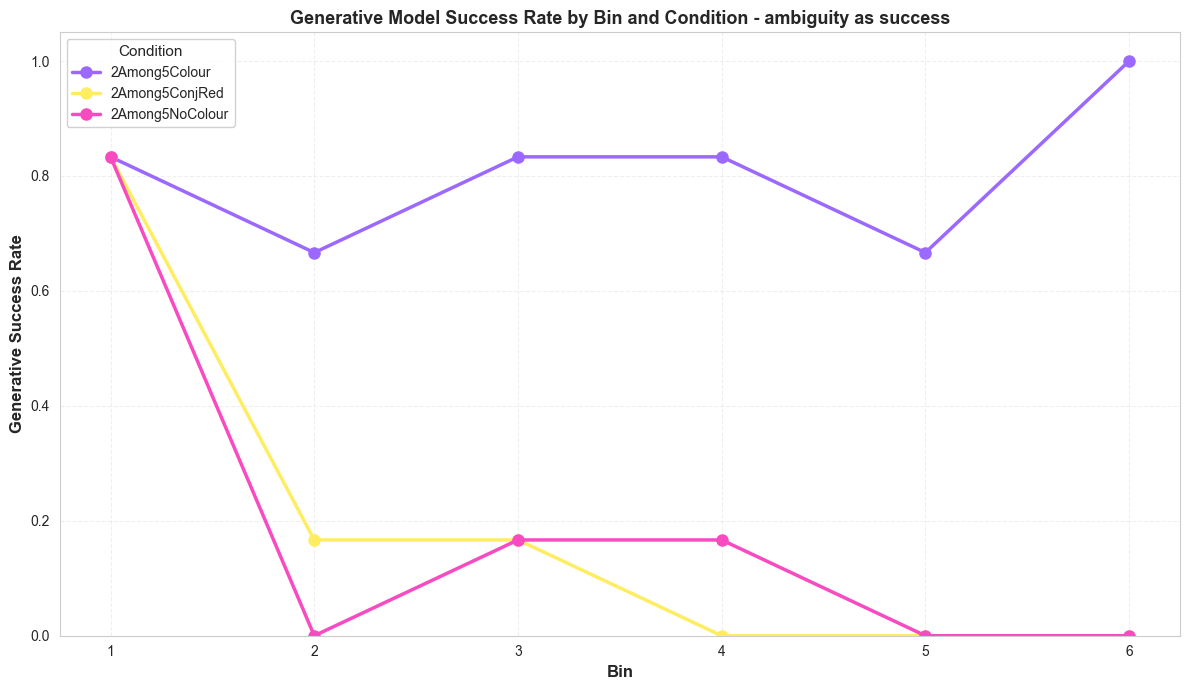

In [43]:
# Plot generative success by bin with lines for each condition
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each condition
colours = {
    '2Among5Colour': "#9B69FF",
    '2Among5ConjRed': "#FFED61",
    '2Among5NoColour': "#F84AC1",

}
NoDistractorsExl_AS = generative_success_AS[
    (generative_success_AS['condition'] != 'NoDistractors') & 
    (generative_success_AS['bin'] != 0)
]
# Get unique conditions and bins
conditions = sorted(NoDistractorsExl_AS['condition'].unique())
bins = sorted(NoDistractorsExl_AS['bin'].unique())

# Create x-axis labels with bin ranges
# Assuming bins are numbered 1, 2, 3, etc. representing ranges
bin_labels = [f"{int(b)}" for b in bins]

# Plot line for each condition
for condition in conditions:
    condition_data = NoDistractorsExl_AS[NoDistractorsExl_AS['condition'] == condition].sort_values('bin')
    color = colours.get(condition, "#333333")  # Default color if condition not in dict
    ax.plot(condition_data['bin'], condition_data['generative_success'], 
            marker='o', linewidth=2.5, markersize=8, label=condition, color=color)

# Formatting
ax.set_xlabel('Bin', fontsize=12, fontweight='bold')
ax.set_ylabel('Generative Success Rate', fontsize=12, fontweight='bold')
ax.set_title('Generative Model Success Rate by Bin and Condition - ambiguity as success', fontsize=13, fontweight='bold')
ax.set_xticks(bins)
ax.set_xticklabels(bin_labels)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(title='Condition', fontsize=10, title_fontsize=11, loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

## 5. Generative Fidelity

In [ ]:
# Identify fidelity columns (excluding notes which is scored separately)
err_cols = ['err_no_distractors', 'err_no_target', 'err_wrong_manip', 'err_new_target_id', 'err_new_target_unid', 'err_extra_distractors', 'err_font_change', 'err_rotation', 'err_movement', 'err_enlarge_target', 'err_enlarge_distractors', 'err_target_centre', 'err_circular_motion', 'err_id_change_before', 'err_id_change_after', 'err_vanishing',  'err_merge']
print(len(err_cols))
fidelity_cols = [ 'fidelity_score_total', 'fidelity_omission', 'fidelity_numeric', 'fidelity_temporal', 'fidelity_physical_vanishing']
notes_col = 'notes'

print(f"Fidelity component columns: {fidelity_cols}")
print(f"Notes column (scored but not in denominator): {notes_col}")

# Fidelity Analysis: Count per fidelity type (overall)
print("\n" + "=" * 60)
print("1. FIDELITY COMPONENT COUNTS (Overall)")
print("=" * 60)
# Convert err_X columns to numeric and count 1s (errors present)
err_count_overall = {}
for col in fidelity_cols:
    if col.startswith('err_'):
        # Convert to numeric and count 1s
        err_count_overall[col] = (pd.to_numeric(veo_data_edit[col], errors='coerce') == 1).sum()
    else:
        # For fidelity_score_total and fidelity_* columns, count non-null values
        err_count_overall[col] = veo_data_edit[col].notna().sum()

fidelity_counts_overall = pd.Series(err_count_overall)
print("\nCounts of 1s (errors present) per error metric:")
print(fidelity_counts_overall)

# Fidelity Analysis: Count per condition per fidelity type
print("\n" + "=" * 60)
print("2. FIDELITY COMPONENT COUNTS BY CONDITION")
print("=" * 60)
fidelity_counts_by_cond = veo_data.groupby('condition').apply(
    lambda df: pd.Series({
        col: (pd.to_numeric(df[col], errors='coerce') == 1).sum() if col.startswith('err_') 
             else df[col].notna().sum()
        for col in fidelity_cols
    })
)
print("\n", fidelity_counts_by_cond)
fidelity_counts_by_cond.to_csv('../Analysis/fidelity_counts_by_condition.csv')
print("\n✓ Saved to: Analysis/fidelity_counts_by_condition.csv")

# Fidelity Analysis: Averages per type and condition
# Note: Total fidelity = (sum of components) / (total possible components excluding notes)
# i.e., divide by len(fidelity_cols) not len(fidelity_cols) + 1
print("\n" + "=" * 60)
print("3. FIDELITY AVERAGES BY CONDITION AND TYPE")
print("=" * 60)

fidelity_avg_by_cond = veo_data.groupby('condition')[fidelity_cols].mean().round(4)
print("\nMean fidelity scores by condition:")
print(fidelity_avg_by_cond)

# Create binary notes indicator (1 if notes present, 0 if null)
veo_data['notes_present'] = veo_data[notes_col].notna().astype(int)

# Notes: count and report presence by condition
print("\nNotes presence by condition (count with notes, proportion with notes):")
for cond in sorted(veo_data['condition'].unique()):
    cond_data = veo_data[veo_data['condition'] == cond]
    count_notes = cond_data['notes_present'].sum()
    total = len(cond_data)
    prop_notes = count_notes / total
    print(f"  {cond}: {int(count_notes)} trials with notes ({prop_notes:.3f})")

# Calculate composite fidelity score (average of components, excluding notes from denominator)
print("\n--- Composite Fidelity Scores (video_fidelity / total_possible) ---")
print("Note: Notes included in score but NOT counted in total_possible denominator")
veo_data['fidelity_composite'] = (veo_data[fidelity_cols].sum(axis=1) / len(fidelity_cols)).round(4)

# Fidelity with notes scored as binary (1 if present, 0 if absent)
veo_data['fidelity_with_notes'] = ((veo_data[fidelity_cols].sum(axis=1) + veo_data['notes_present']) / len(fidelity_cols)).round(4)

print(f"\nComposite Fidelity Statistics (components only):")
print(f"  Mean: {veo_data['fidelity_composite'].mean():.4f}")
print(f"  Std:  {veo_data['fidelity_composite'].std():.4f}")
print(f"  Min:  {veo_data['fidelity_composite'].min():.4f}")
print(f"  Max:  {veo_data['fidelity_composite'].max():.4f}")

print(f"\nComposite Fidelity with Notes (notes binary 0/1, but not in denominator):")
print(f"  Mean: {veo_data['fidelity_with_notes'].mean():.4f}")
print(f"  Std:  {veo_data['fidelity_with_notes'].std():.4f}")
print(f"  Min:  {veo_data['fidelity_with_notes'].min():.4f}")
print(f"  Max:  {veo_data['fidelity_with_notes'].max():.4f}")

# Fidelity by success/failure and condition
print("\n" + "=" * 60)
print("4. FIDELITY AVERAGES BY CONDITION AND SUCCESS STATUS")
print("=" * 60)
fidelity_by_cond_success = veo_data.groupby(['condition', 'success'])[fidelity_cols + ['fidelity_composite', 'fidelity_with_notes']].mean().round(4)
print("\n", fidelity_by_cond_success)
fidelity_by_cond_success.to_csv('../Analysis/fidelity_by_condition_success.csv')
print("\n✓ Saved to: Analysis/fidelity_by_condition_success.csv")

# Fidelity by bin (all trials)
print("\n" + "=" * 60)
print("5. FIDELITY AVERAGES BY BIN")
print("=" * 60)
fidelity_by_bin = veo_data.groupby('bin_y')[fidelity_cols + ['fidelity_composite', 'fidelity_with_notes']].mean().round(4)
print("\n", fidelity_by_bin)
fidelity_by_bin.to_csv('../Analysis/fidelity_by_bin.csv')
print("\n✓ Saved to: Analysis/fidelity_by_bin.csv")



18
Fidelity component columns: ['fidelity_score_total', 'fidelity_omission', 'fidelity_numeric', 'fidelity_temporal', 'fidelity_physical_vanishing']
Notes column (scored but not in denominator): notes

1. FIDELITY COMPONENT COUNTS (Overall)

Counts of 1s (errors present) per error metric:
fidelity_score_total           114
fidelity_omission              114
fidelity_numeric               114
fidelity_temporal              114
fidelity_physical_vanishing    114
dtype: int64

2. FIDELITY COMPONENT COUNTS BY CONDITION

                  fidelity_score_total  fidelity_omission  fidelity_numeric  \
condition                                                                    
2Among5Colour                      36                 36                36   
2Among5ConjRed                     36                 36                36   
2Among5NoColour                    36                 36                36   
NoDistractors                       6                  6                 6   

        

## 6. Additional Descriptive Statistics

In [41]:
print("\n" + "=" * 60)
print("ADDITIONAL DESCRIPTIVE STATISTICS")
print("=" * 60)

# 6a. Success by number of distractors (if column exists)
if 'num_distractors' in veo_data.columns:
    print("\n--- Success Rate by Number of Distractors ---")
    distractor_success = veo_data.groupby('num_distractors')['success'].agg(
        ['mean', 'sum', 'count']
    ).reset_index()
    distractor_success.columns = ['num_distractors', 'success_rate', 'n_success', 'n_total']
    print(distractor_success.to_string(index=False))

# 6b. Effect size (Cohen's h) for success between conditions
print("\n--- Effect Sizes (Cohen's h) Between Conditions ---")
conditions = success_by_condition['condition'].values
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        c1_success = success_by_condition.iloc[i]['success_rate']
        c2_success = success_by_condition.iloc[j]['success_rate']
        h = 2 * (np.arcsin(np.sqrt(c1_success)) - np.arcsin(np.sqrt(c2_success)))
        print(f"  {conditions[i]} vs {conditions[j]}: h = {h:.4f}")

# 6c. Trial count distribution
print("\n--- Trial Count by Condition and Bin ---")
trial_counts = veo_data.groupby(['condition', 'bin_y']).size().reset_index(name='count')
trial_counts_pivot = trial_counts.pivot(index='condition', columns='bin_y', values='count')
print(trial_counts_pivot)

# 6d. Success rate stability (coefficient of variation within conditions)
print("\n--- Success Rate Variability within Conditions (Bin-level) ---")
for condition in veo_data['condition'].unique():
    cond_data = generative_success[generative_success['condition'] == condition]
    bin_success_rates = cond_data['generative_success'].values
    if len(bin_success_rates) > 1:
        cv = np.std(bin_success_rates) / np.mean(bin_success_rates)
        range_val = bin_success_rates.max() - bin_success_rates.min()
        print(f"  {condition}: CV = {cv:.4f}, Range = [{bin_success_rates.min():.4f}, {bin_success_rates.max():.4f}]")


ADDITIONAL DESCRIPTIVE STATISTICS

--- Success Rate by Number of Distractors ---
 num_distractors  success_rate  n_success  n_total
               0      1.000000          6        6
               1      1.000000          4        4
               2      0.833333          5        6
               3      1.000000          2        2
               4      0.500000          3        6
               5      0.400000          2        5
               6      0.250000          2        8
               7      0.000000          0        2
               8      0.000000          0        3
               9      0.285714          2        7
              10      0.666667          2        3
              11      0.000000          0        2
              12      0.000000          0        1
              14      0.000000          0        4
              16      0.000000          0        1
              17      0.000000          0        3
              20      0.000000          0        1
